<a href="https://colab.research.google.com/github/Yashb404/MUJ-ML-Lab/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



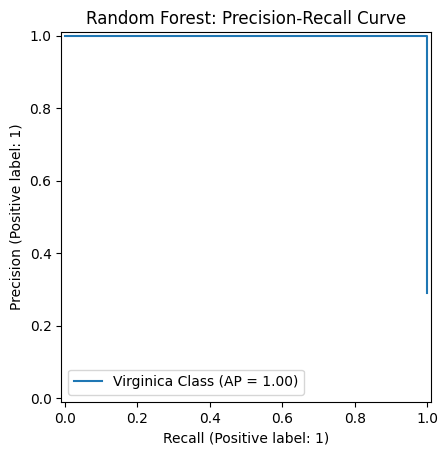

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, PrecisionRecallDisplay
from sklearn.preprocessing import label_binarize

# 1) Load the dataset and split it into training and testing sets
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2) Train Random Forest classifier using varying hyperparameters
# Model 1: 10 estimators, depth 2
rf_1 = RandomForestClassifier(n_estimators=10, max_depth=2, random_state=42)
rf_1.fit(X_train, y_train)

# Model 2: 100 estimators, depth None (unlimited)
rf_2 = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf_2.fit(X_train, y_train)

# 3) Predict class labels for the test data
y_pred = rf_2.predict(X_test)

# 4) Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=data.target_names))

# Precision recall curve (Binarized to prevent Python crash on 3-class data)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = rf_2.predict_proba(X_test)
PrecisionRecallDisplay.from_predictions(y_test_bin[:, 2], y_score[:, 2], name="Virginica Class")
plt.title("Random Forest: Precision-Recall Curve")
plt.show()

Model 1 (estimators=10, lr=0.5) Accuracy: 1.0000
Model 2 (estimators=50, lr=1.0) Accuracy: 1.0000

--- Final Model Evaluation ---
Accuracy: 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



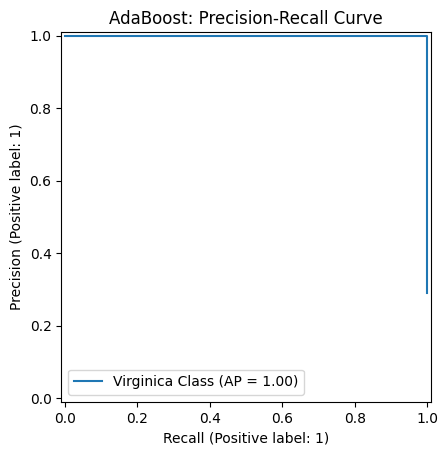

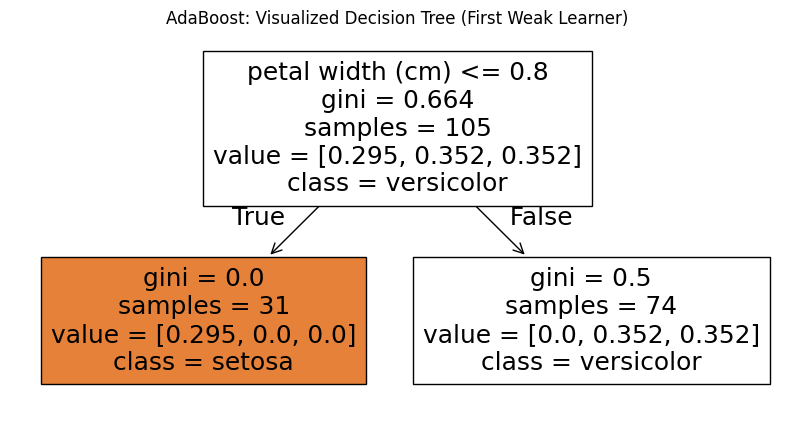

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, PrecisionRecallDisplay
from sklearn.preprocessing import label_binarize
from sklearn.tree import plot_tree

# 1) Load the dataset and split it into training and testing sets
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Investigate hyperparameter impact (estimators and learning rate)
ada_1 = AdaBoostClassifier(n_estimators=10, learning_rate=0.5, random_state=42)
ada_1.fit(X_train, y_train)
print(f"Model 1 (estimators=10, lr=0.5) Accuracy: {accuracy_score(y_test, ada_1.predict(X_test)):.4f}")

ada_2 = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
ada_2.fit(X_train, y_train)
print(f"Model 2 (estimators=50, lr=1.0) Accuracy: {accuracy_score(y_test, ada_2.predict(X_test)):.4f}")

# 2) Predict class labels for the test data (using Model 2)
y_pred = ada_2.predict(X_test)

# 3) Evaluate the model
print("\n--- Final Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=data.target_names))

# Precision recall curve (Binarized for 'Virginica' to prevent multiclass crash)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = ada_2.predict_proba(X_test)
PrecisionRecallDisplay.from_predictions(y_test_bin[:, 2], y_score[:, 2], name="Virginica Class")
plt.title("AdaBoost: Precision-Recall Curve")
plt.show()

# Visualized the decision tree (First weak learner)
plt.figure(figsize=(10, 5))
plot_tree(ada_2.estimators_[0], feature_names=data.feature_names, class_names=list(data.target_names), filled=True)
plt.title("AdaBoost: Visualized Decision Tree (First Weak Learner)")
plt.show()